# **1: Setup and Environment**

In [1]:
import os
import time
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision import datasets, transforms
import torchaudio
import torchaudio.transforms as T
import math

# Mount Google Drive to access your audio samples later
from google.colab import drive
drive.mount('/content/drive')

# Set device to GPU if available for faster training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Mounted at /content/drive
Using device: cpu


# **Question 2 - Preparing ReducedMNIST**

**Objective**: Create a "ReducedMNIST" dataset with 1000 training examples and 200 testing examples per digit.

We will download the standard MNIST dataset and use PyTorch's Subset to randomly sample the exact number of examples required. We also apply a basic ToTensor() transform to convert the images to PyTorch tensors.


In [2]:
def get_reduced_mnist(train_samples_per_class=1000, test_samples_per_class=200):
    transform = transforms.Compose([transforms.ToTensor()])

    # Download full MNIST
    full_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    full_test = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

    # Helper function to get balanced subsets
    def create_subset(dataset, samples_per_class):
        indices = []
        targets = dataset.targets.numpy()
        for i in range(10): # 10 digits
            class_indices = np.where(targets == i)[0]
            np.random.shuffle(class_indices)
            indices.extend(class_indices[:samples_per_class])
        return Subset(dataset, indices)

    reduced_train = create_subset(full_train, train_samples_per_class)
    reduced_test = create_subset(full_test, test_samples_per_class)

    return reduced_train, reduced_test

train_set, test_set = get_reduced_mnist()
train_loader = DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False)

print(f"Reduced Train size: {len(train_set)} | Reduced Test size: {len(test_set)}")

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.99MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 134kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.27MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.06MB/s]

Reduced Train size: 10000 | Reduced Test size: 2000


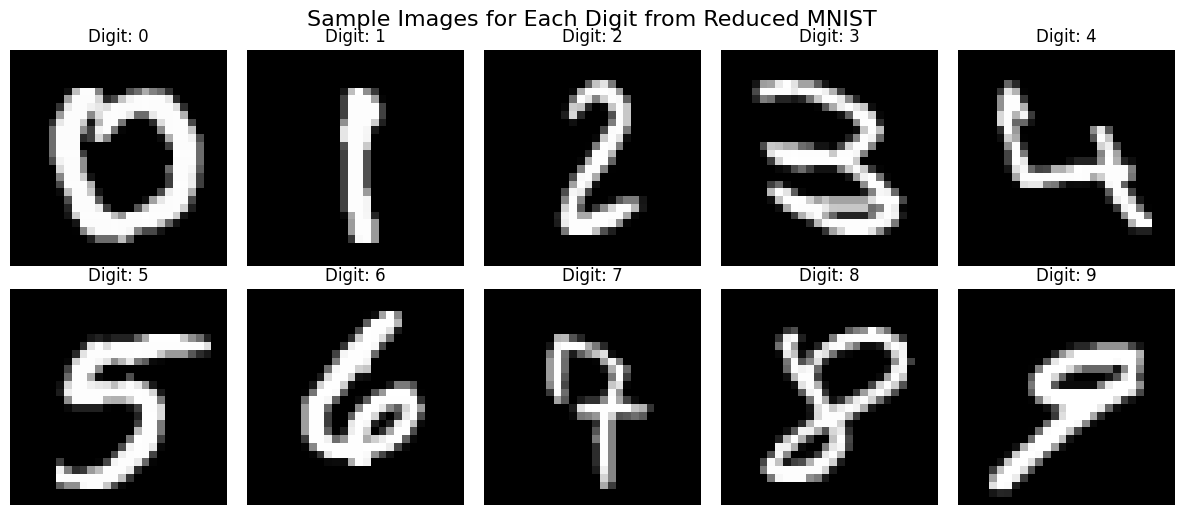

In [5]:
# Collect one sample image for each digit (0-9)
samples_per_digit = {}
for image, label in train_set:
    if label not in samples_per_digit:
        samples_per_digit[label] = image.squeeze().numpy() # Remove channel dim and convert to numpy
    if len(samples_per_digit) == 10:
        break

# Sort samples by digit for consistent display
sorted_samples = sorted(samples_per_digit.items())

# Plot the sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i, (label, image_np) in enumerate(sorted_samples):
    axes[i].imshow(image_np, cmap='gray')
    axes[i].set_title(f'Digit: {label}')
    axes[i].axis('off')

plt.tight_layout()
plt.suptitle('Sample Images for Each Digit from Reduced MNIST', y=1.02, fontsize=16)
plt.show()

# **Question 2 - LeNet-5 Architecture & Training**
LoopObjective: Build a LeNet-5 model adjusted for $28\times28$ images.The standard LeNet expects $32\times32$. Without padding, a $5\times5$ convolution on a $28\times28$ image reduces it to $24\times24$. After pooling and a second convolution, the feature map flattens to 256. I've designed the class to accept different activations and filter counts so we can easily complete part "a" (variations).

In [17]:
class ModifiedLeNet5(nn.Module):
    def __init__(self, activation=nn.ReLU(), filter_1=6, filter_2=16):
        super(ModifiedLeNet5, self).__init__()
        # Convolutional layers
        self.conv1 = nn.Conv2d(1, filter_1, kernel_size=5, stride=1)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(filter_1, filter_2, kernel_size=5, stride=1)

        # Fully connected layers (adjusted for 28x28 input)
        # 28 -> conv1(5x5) -> 24 -> pool(2x2) -> 12 -> conv2(5x5) -> 8 -> pool(2x2) -> 4x4
        self.fc1 = nn.Linear(filter_2 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        self.activation = activation

    def forward(self, x):
        x = self.pool(self.activation(self.conv1(x)))
        x = self.pool(self.activation(self.conv2(x)))
        x = torch.flatten(x, 1) # Flatten for FC layers
        x = self.activation(self.fc1(x))
        x = self.activation(self.fc2(x))
        x = self.fc3(x) # No softmax here, CrossEntropyLoss handles it
        return x

# A universal training and testing function to track timing and accuracy
def train_and_evaluate(model, train_loader, test_loader, epochs=10):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    print(f"Training for {epochs} epochs...")

    start_total_train = time.time()
    # --- TRAINING PHASE ---
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        epoch_start_train = time.time()
        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        epoch_train_time = (time.time() - epoch_start_train) * 1000
        print(f"  Epoch {epoch+1}/{epochs}, Train Loss: {running_loss/len(train_loader):.4f}, Train Time: {epoch_train_time:.1f} ms")

        # --- EPOCH-WISE TESTING PHASE ---
        model.eval()
        correct = 0
        total = 0
        epoch_start_test = time.time()
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        epoch_test_time = (time.time() - epoch_start_test) * 1000
        epoch_accuracy = 100 * correct / total
        print(f"  Epoch {epoch+1}/{epochs}, Test Accuracy: {epoch_accuracy:.1f}%, Test Time: {epoch_test_time:.1f} ms")

    train_time = (time.time() - start_total_train) * 1000 # Total training time

    # --- FINAL TESTING PHASE (to get final accuracy and total test time if desired, though epoch-wise is now present) ---
    # Re-evaluate once at the very end to get the final overall metrics
    start_final_test = time.time()
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    final_test_time = (time.time() - start_final_test) * 1000
    final_accuracy = 100 * correct / total
    print(f"Final Test Accuracy: {final_accuracy:.1f}% | Total Test Time: {final_test_time:.1f} ms")

    return final_accuracy, train_time, final_test_time

# **Running Base Model & Variations (Q2.a)**

Objective: Run the base model using ReLU, then run two variations.

**Variation 1**: Swap ReLU for Tanh (changing activation).

**Variation 2**: Double the number of filters in the Convolutional layers.

In [18]:
print("--- Base Model (ReLU, Filters: 6 & 16) ---")
base_model = ModifiedLeNet5(activation=nn.ReLU())
acc_base, train_t_base, test_t_base = train_and_evaluate(base_model, train_loader, test_loader)
print(f"Accuracy: {acc_base:.1f}% | Train Time: {train_t_base:.1f} ms | Test Time: {test_t_base:.1f} ms\n")

print("--- Variation 1: Tanh Activation ---")
var1_model = ModifiedLeNet5(activation=nn.Tanh())
acc_v1, train_t_v1, test_t_v1 = train_and_evaluate(var1_model, train_loader, test_loader)
print(f"Accuracy: {acc_v1:.1f}% | Train Time: {train_t_v1:.1f} ms | Test Time: {test_t_v1:.1f} ms\n")

print("--- Variation 2: Double Filters (12 & 32) ---")
var2_model = ModifiedLeNet5(activation=nn.ReLU(), filter_1=12, filter_2=32)
acc_v2, train_t_v2, test_t_v2 = train_and_evaluate(var2_model, train_loader, test_loader)
print(f"Accuracy: {acc_v2:.1f}% | Train Time: {train_t_v2:.1f} ms | Test Time: {test_t_v2:.1f} ms\n")

# Use these outputs to fill the table required in Question 2b.

--- Base Model (ReLU, Filters: 6 & 16) ---
Training for 10 epochs...
  Epoch 1/10, Loss: 1.0049
  Epoch 2/10, Loss: 0.4016
  Epoch 3/10, Loss: 0.2908
  Epoch 4/10, Loss: 0.2264
  Epoch 5/10, Loss: 0.1810
  Epoch 6/10, Loss: 0.1467
  Epoch 7/10, Loss: 0.1253
  Epoch 8/10, Loss: 0.1108
  Epoch 9/10, Loss: 0.0914
  Epoch 10/10, Loss: 0.0809
  Test Accuracy: 96.4%
Accuracy: 96.4% | Train Time: 33051.8 ms | Test Time: 365.6 ms

--- Variation 1: Tanh Activation ---
Training for 10 epochs...
  Epoch 1/10, Loss: 0.8440
  Epoch 2/10, Loss: 0.3279
  Epoch 3/10, Loss: 0.2431
  Epoch 4/10, Loss: 0.1863
  Epoch 5/10, Loss: 0.1456
  Epoch 6/10, Loss: 0.1174
  Epoch 7/10, Loss: 0.0918
  Epoch 8/10, Loss: 0.0782
  Epoch 9/10, Loss: 0.0643
  Epoch 10/10, Loss: 0.0548
  Test Accuracy: 96.8%
Accuracy: 96.8% | Train Time: 34881.5 ms | Test Time: 596.2 ms

--- Variation 2: Double Filters (12 & 32) ---
Training for 10 epochs...
  Epoch 1/10, Loss: 0.8129
  Epoch 2/10, Loss: 0.3156
  Epoch 3/10, Loss: 0.2094

#**Question 3 - Speech Recognition & Augmentation**

**Objective**: Convert speech .wav files into spectrograms and train a CNN.

Since you are mounting your Google Drive, we need a Custom Dataset class that can iterate through your folders, read the audio using torchaudio, and apply the requested augmentations.

NOTE to User: You must ensure your data_dir points to the correct folder in your drive where the .wav files are stored. The code assumes a folder structure where audio files are in subfolders named by their digit (e.g., .../audio-samples/0/xyz.wav).

In [19]:
class SpeechDigitDataset(Dataset):
    def __init__(self, data_dir, is_train=True, audio_aug=False, img_aug=False):
        self.data_dir = data_dir
        self.filepaths = []
        self.labels = []
        self.audio_aug = audio_aug
        self.img_aug = img_aug

        # Determine the subdirectory (train or test)
        subset_dir = 'Train' if is_train else 'Test'
        full_subset_path = os.path.join(data_dir, subset_dir)

        if not os.path.exists(full_subset_path):
            raise FileNotFoundError(f"Directory not found: {full_subset_path}")

        # Scan subdirectory for .wav files
        for file in os.listdir(full_subset_path):
            if file.endswith('.wav'):
                filepath = os.path.join(full_subset_path, file)
                self.filepaths.append(filepath)
                # Extract label from filename (e.g., 'audio_0_123.wav' -> 0)
                try:
                    # Extract the number after the first underscore and before the .wav extension
                    label = int(file.split('_')[1].split('.')[0])
                    self.labels.append(label)
                except (IndexError, ValueError):
                    print(f"Warning: Could not parse label from filename {file}. Skipping.")

        # Spectrogram converter
        self.spectrogramer = T.MelSpectrogram(sample_rate=16000, n_mels=64)

        # Image Resizer (to force spectrograms to uniform size like 32x32 for our CNN)
        self.resize = transforms.Resize((32, 32))

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        path = self.filepaths[idx]
        label = self.labels[idx]

        # 1. Load Audio
        waveform, sample_rate = torchaudio.load(path)

        # --- Audio Augmentation (Part b) ---
        if self.audio_aug:
            # Add random noise
            noise = torch.randn_like(waveform) * 0.005
            waveform = waveform + noise
            # Speed up/down 3% using resampling hack
            speed_factor = random.choice([0.97, 1.03])
            new_sr = int(sample_rate * speed_factor)
            resampler = T.Resample(orig_freq=sample_rate, new_freq=new_sr)
            waveform = resampler(waveform)

        # 2. Convert to Spectrogram Image
        spec = self.spectrogramer(waveform)
        # Convert power to dB (Log scale)
        spec = torchaudio.transforms.AmplitudeToDB()(spec)

        # Resize to standard size (e.g., 32x32) so it fits into standard CNNs easily
        spec = self.resize(spec)

        # --- Image Augmentation (Part c) ---
        if self.img_aug:
            # Squeeze/Expand horizontally by 3% (resize width, then crop/pad to 32x32)
            width_factor = random.choice([0.97, 1.03])
            new_w = int(32 * width_factor)
            temp_resize = transforms.Resize((32, new_w))
            spec = temp_resize(spec)

            # Crop or pad to get back to 32x32 exactly
            if new_w > 32:
                spec = transforms.CenterCrop(32)(spec)
            else:
                pad_amount = 32 - new_w
                spec = nn.functional.pad(spec, (pad_amount//2, pad_amount - pad_amount//2)) # noqa: E501

            # Add noise to image
            img_noise = torch.randn_like(spec) * 0.05
            spec = spec + img_noise

        return spec, label

# UPDATE THIS PATH to where your files are in Google Drive
YOUR_AUDIO_PATH = "/content/drive/MyDrive/audio-dataset"

# Because we resized the spectrograms to 32x32, standard LeNet works!
# Let's define a 32x32 variant just for Q3.
class SpectrogramCNN(nn.Module):
    def __init__(self):
        super(SpectrogramCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120) # 32->28->14->10->5
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

Audio data path: /content/drive/MyDrive/audio-dataset
Number of fetched training audio samples: 1200
Number of fetched testing audio samples: 300

--- Visualizing Spectrogram Samples for Each Digit (0-9) from Training Data ---


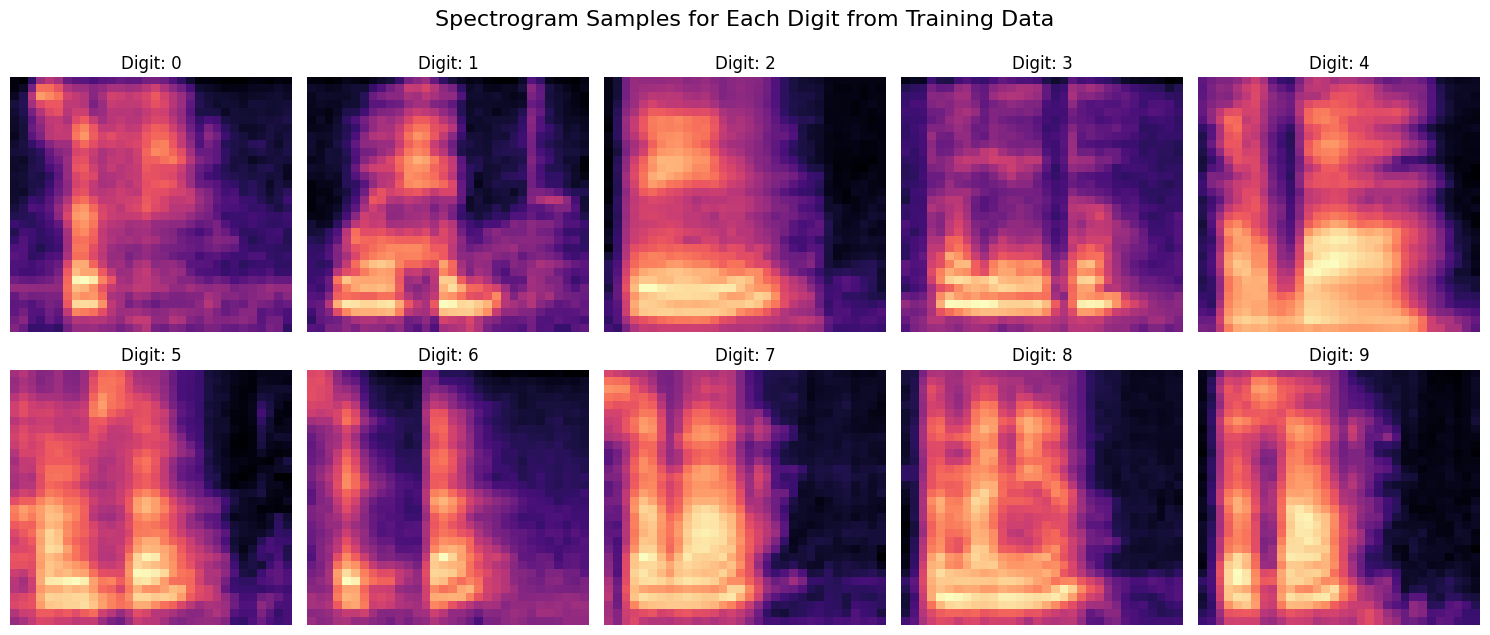


Data flow for Digit: 9 (from file: U13_9.wav):
  1. Initial Waveform Shape: torch.Size([1, 12800]) (Channels, Samples)
  2. Spectrogram (before resize) Shape: torch.Size([1, 64, 65]) (Channels, Freq_bins, Time_frames)
  3. Final Spectrogram (after resize) Shape: torch.Size([1, 32, 32]) (Channels, Height, Width)


In [20]:
print(f"Audio data path: {YOUR_AUDIO_PATH}")

# Initialize datasets to count samples
try:
    train_ds_info = SpeechDigitDataset(YOUR_AUDIO_PATH, is_train=True, audio_aug=False, img_aug=False)
    test_ds_info = SpeechDigitDataset(YOUR_AUDIO_PATH, is_train=False, audio_aug=False, img_aug=False)

    print(f"Number of fetched training audio samples: {len(train_ds_info)}")
    print(f"Number of fetched testing audio samples: {len(test_ds_info)}")

    if len(train_ds_info) == 0 or len(test_ds_info) == 0:
        print("Warning: One or both datasets are empty. Please check YOUR_AUDIO_PATH and the subdirectory names ('Train', 'Test').")
except FileNotFoundError as e:
    print(f"Error: {e}. Make sure the 'audio-dataset/Train' and 'audio-dataset/Test' directories exist in your Google Drive.")
except Exception as e:
    print(f"An unexpected error occurred while loading dataset info: {e}")


import matplotlib.pyplot as plt

print("\n--- Visualizing Spectrogram Samples for Each Digit (0-9) from Training Data ---")

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

# Create a temporary dataset for visualization (no augmentation, so we see the 'raw' spectrograms)
vis_ds = SpeechDigitDataset(YOUR_AUDIO_PATH, is_train=True, audio_aug=False, img_aug=False)

if len(vis_ds) > 0:
    # Collect one spectrogram sample for each digit
    samples_per_digit = {}
    flow_sample_info = None

    for spec, label in vis_ds:
        if label not in samples_per_digit:
            samples_per_digit[label] = spec.squeeze().numpy() # Remove channel dim and convert to numpy
            if flow_sample_info is None: # Store info for the first collected sample for flow visualization
                flow_sample_info = {'spec': spec, 'label': label, 'filepath': vis_ds.filepaths[vis_ds.labels.index(label)]}
        if len(samples_per_digit) == 10:
            break

    # Sort samples by digit for consistent display
    sorted_samples = sorted(samples_per_digit.items())

    for i, (label, spec_np) in enumerate(sorted_samples):
        axes[i].imshow(spec_np, origin='lower', aspect='auto', cmap='magma')
        axes[i].set_title(f'Digit: {label}')
        axes[i].axis('off')

    plt.tight_layout()
    plt.suptitle('Spectrogram Samples for Each Digit from Training Data', y=1.05, fontsize=16)
    plt.show()

    # Print data visualization flow for the first collected sample
    if flow_sample_info:
        label = flow_sample_info['label']
        filepath = flow_sample_info['filepath']
        spec = flow_sample_info['spec']
        print(f"\nData flow for Digit: {label} (from file: {os.path.basename(filepath)}):")

        # Load raw waveform again to show intermediate steps
        waveform, sample_rate = torchaudio.load(filepath)
        print(f"  1. Initial Waveform Shape: {waveform.shape} (Channels, Samples)")

        # Convert to spectrogram (before resizing)
        intermediate_spec = vis_ds.spectrogramer(waveform)
        intermediate_spec = torchaudio.transforms.AmplitudeToDB()(intermediate_spec)
        print(f"  2. Spectrogram (before resize) Shape: {intermediate_spec.shape} (Channels, Freq_bins, Time_frames)")

        print(f"  3. Final Spectrogram (after resize) Shape: {spec.shape} (Channels, Height, Width)")

else:
    print("No data available in the visualization dataset to plot.")

#**Running the 4 scenarios for Question 3**
**Objective**: Run experiments A, B, C, and D based on combinations of audio and image augmentations.(Note: The code below creates the datasets and triggers the training loop. If your dataset is large, consider reducing the number of epochs while testing).

In [21]:
# Function to quickly build loader, model and train
def run_speech_experiment(audio_aug, img_aug, exp_name):
    print(f"\n--- Running Experiment: {exp_name} ---")

    # Initialize datasets. (Ideally, separate train/test folders. Using same dir here as placeholder)
    try:
        train_ds = SpeechDigitDataset(YOUR_AUDIO_PATH, is_train=True, audio_aug=audio_aug, img_aug=img_aug)
        # For testing, we turn off augmentations to test raw performance
        test_ds = SpeechDigitDataset(YOUR_AUDIO_PATH, is_train=False, audio_aug=False, img_aug=False)

        if len(train_ds) == 0:
            print("Warning: No audio files found. Check YOUR_AUDIO_PATH.")
            return

        train_ldr = DataLoader(train_ds, batch_size=32, shuffle=True)
        test_ldr = DataLoader(test_ds, batch_size=32, shuffle=False)

        model = SpectrogramCNN()
        acc, t_time, eval_time = train_and_evaluate(model, train_ldr, test_ldr, epochs=10)
        print(f"Result -> Accuracy: {acc:.1f}% | Train Time: {t_time:.1f}ms")
    except Exception as e:
        print(f"Could not complete experiment. Error: {e}")

# Part A: No augmentation
run_speech_experiment(audio_aug=False, img_aug=False, exp_name="Part A: Base CNN (No Augmentation)")

# Part B: Audio augmentation only
run_speech_experiment(audio_aug=True, img_aug=False, exp_name="Part B: Audio Augmentation (Speed +/- 3%, Noise)")

# Part C: Image augmentation only
run_speech_experiment(audio_aug=False, img_aug=True, exp_name="Part C: Spectrum Augmentation (Squeeze/Expand 3%, Noise)")

# Part D: Audio AND Image augmentation combined
run_speech_experiment(audio_aug=True, img_aug=True, exp_name="Part D: Combined Augmentation")


--- Running Experiment: Part A: Base CNN (No Augmentation) ---
Training for 10 epochs...
  Epoch 1/10, Loss: 1.6619
  Epoch 2/10, Loss: 0.5500
  Epoch 3/10, Loss: 0.2297
  Epoch 4/10, Loss: 0.1484
  Epoch 5/10, Loss: 0.1026
  Epoch 6/10, Loss: 0.0513
  Epoch 7/10, Loss: 0.0221
  Epoch 8/10, Loss: 0.0156
  Epoch 9/10, Loss: 0.0261
  Epoch 10/10, Loss: 0.0744
  Test Accuracy: 90.3%
Result -> Accuracy: 90.3% | Train Time: 117129.8ms

--- Running Experiment: Part B: Audio Augmentation (Speed +/- 3%, Noise) ---
Training for 10 epochs...
  Epoch 1/10, Loss: 1.8934
  Epoch 2/10, Loss: 0.8920
  Epoch 3/10, Loss: 0.4296
  Epoch 4/10, Loss: 0.2718
  Epoch 5/10, Loss: 0.1842
  Epoch 6/10, Loss: 0.1185
  Epoch 7/10, Loss: 0.1045
  Epoch 8/10, Loss: 0.1051
  Epoch 9/10, Loss: 0.0675
  Epoch 10/10, Loss: 0.0778
  Test Accuracy: 85.0%
Result -> Accuracy: 85.0% | Train Time: 124025.1ms

--- Running Experiment: Part C: Spectrum Augmentation (Squeeze/Expand 3%, Noise) ---
Training for 10 epochs...
  Ep